# E11 - Structure-distance SOTA decision: H44 vs H55

**Author** - kj &nbsp;|&nbsp; **Goal** - decide the single structure metric the library ships, on better material

The library ships **one** structure number beside SMD. The two finalists are **E08-H44** position-augmented
Wasserstein (a true metric) and **E10-H55** the OPW order-gap `OPW - SMD` (translation-invariant, a score). E10
could only test content-invariance with an embedding-jitter proxy on one article. E11 decides on real material:

- **Two articles** - IBM exec-summaries and the Wergeland AI-in-society curriculum (cross-fixture replication)
- **True paraphrase** - opus-mt back-translation (per-statement reword, order preserved) + same-model a/b regenerations
- **The gates** - content-invariance (a reword must read ~0), scramble-monotonicity, translation-invariance (pure shift), diffuse realism, and metric-vs-score

The decisive question: which single number means *arrangement changed, not meaning* - reads ~0 on a paraphrase and large on a reorder.

## GPU selection

mmBERT statement embedding runs on the RTX 5000 Ada (GPU 2), pinned by UUID. The OT math is CPU numpy.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu  # RTX 5000 Ada
os.environ["TOKENIZERS_PARALLELISM"] = "false"; os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(), "|",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.11.0+cu130 | cuda True | NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from rich.console import Console
from rich.table import Table

import ot
from docdistance.distance import cost_matrix, smd, transport_plan, closeness, SMD_MAX
from docdistance.encoders import load_encoder

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("imports ready | POT", ot.__version__)

imports ready | POT 0.9.6.post1


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
print(f"SEED={SEED}")

SEED=0


## Configuration

The two mechanisms and their pre-registered parameters, the fixture paths, the displacement binning, and the
decision gates. `LAM=0.25` is the E08-H44 headline weight; the OPW parameters are the Su & Hua / E10 defaults.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
FIX = ROOT / "data/processed/structure-fixture"
REPORT = ROOT / "reports/E11-structure-sota-decision.json"

LAM = 0.25                       # E08-H44 position-augmented Wasserstein weight
OPW_L1, OPW_L2, OPW_SIG = 50.0, 0.1, 1.0   # E10-H55 Su & Hua OPW defaults
N_BINS = 6                       # displacement bins for the scramble sweep
SHIFTS = [2, 4]                  # pure-shift magnitudes (rigid positional translation)
PER_BIN = 12                     # reorder perms sampled per bin per base
TRI_TRIALS = 200                 # triangle-inequality sampled triples
CONTENT_BAR = 0.10               # content-invariance: paraphrase reading <= this * scramble-top-bin

DOCS = json.loads((FIX / "statements.json").read_text())
PAIRS = json.loads((FIX / "pairs.json").read_text())
REORDER = json.loads((FIX / "reorder_pool.json").read_text())
META = json.loads((FIX / "meta.json").read_text())
BASES = META["base_docs"]
ARTICLE = {b: DOCS[b]["article"] for b in BASES}

ENC = load_encoder("torch", offline=True, device="cuda")
DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

t = Table(title="E11 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Device", DEVICE)
t.add_row("H44 (metric)", f"position-augmented Wasserstein, lambda={LAM}")
t.add_row("H55 (score)", f"OPW order-gap, lambda1={OPW_L1} lambda2={OPW_L2} sigma={OPW_SIG}")
t.add_row("Articles", " + ".join(sorted(set(ARTICLE.values()))))
t.add_row("Bases", f"{len(BASES)} ({', '.join(BASES)})")
t.add_row("Paraphrase pairs", str(len(PAIRS["paraphrase"])))
t.add_row("Scramble", f"{N_BINS} displacement bins, {PER_BIN}/bin/base")
t.add_row("Content-invariance bar", f"paraphrase reading <= {CONTENT_BAR} x scramble top-bin")
console.print(t)

                                         E11 configuration                                          
  Device                    NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition                 
  H44 (metric)              position-augmented Wasserstein, lambda=0.25                             
  H55 (score)               OPW order-gap, lambda1=50.0 lambda2=0.1 sigma=1.0                       
  Articles                  ibm + wergeland                                                         
  Bases                     10 (gold, gold-2, v1, v2, opus, sonnet, haiku, werg-a, werg-b, werg-c)  
  Paraphrase pairs          14                                                                      
  Scramble                  6 displacement bins, 12/bin/base                                        
  Content-invariance bar    paraphrase reading <= 0.1 x scramble top-bin

## Mechanisms

H44 and H55 reuse E08/E10 code verbatim. H44 is the exact OT under the fused cost `sqrt((1-lambda) d_sem^2 +
lambda d_pos^2)`. H55 is the order-gap `OPW - SMD`: OPW (Su & Hua) is the content transport regularized by an
inverse-difference-moment term and a Gaussian temporal prior (log-stabilized Sinkhorn), and subtracting SMD cancels
the content component, leaving the extra cost the order constraint forces. `naive_footrule` is the model-free floor.

In [5]:
def pos_vec(n):
    return np.arange(n) / max(n - 1, 1)

# --- E08-H44 position-augmented Wasserstein (metric) ---
def posaug_cost(EA, EB, lam, posA=None, posB=None):
    d = cost_matrix(EA, EB)
    pa = pos_vec(len(EA)) if posA is None else posA
    pb = pos_vec(len(EB)) if posB is None else posB
    dp = np.abs(pa[:, None] - pb[None, :])
    return np.sqrt((1 - lam) * d ** 2 + lam * dp ** 2)

def posaug_smd(EA, EB, lam=LAM, posA=None, posB=None):
    a, b = np.full(len(EA), 1 / len(EA)), np.full(len(EB), 1 / len(EB))
    return float(ot.emd2(a, b, posaug_cost(EA, EB, lam, posA, posB)))

# --- E10-H55 OPW order-gap (score) ---
def opw_transport(EA, EB, l1=OPW_L1, l2=OPW_L2, sig=OPW_SIG, iters=100):
    N, M = len(EA), len(EB); D = cost_matrix(EA, EB)
    i = (np.arange(1, N + 1) / N)[:, None]; j = (np.arange(1, M + 1) / M)[None, :]
    mid = np.abs(i - j) / np.sqrt(1 / N ** 2 + 1 / M ** 2)
    logP = -mid ** 2 / (2 * sig ** 2) - np.log(sig * np.sqrt(2 * np.pi))
    S = l1 / ((i - j) ** 2 + 1)
    logK = logP + (S - D) / l2; logK = logK - logK.max(); K = np.exp(logK)
    a, b = np.full(N, 1 / N), np.full(M, 1 / M); u = np.ones(N) / N
    for _ in range(iters):
        v = b / (K.T @ u + 1e-300); u = a / (K @ v + 1e-300)
    T = u[:, None] * K * v[None, :]
    return float((T * D).sum())

def opw_gap(EA, EB):
    return opw_transport(EA, EB) - smd(EA, EB)

def naive_footrule(EA, EB):
    order = np.argsort(np.argsort(cost_matrix(EA, EB).argmin(1)))
    n = len(order)
    return 0.0 if n < 2 else float(np.abs(order - np.arange(n)).sum()) / (n * n // 2)

H44 = lambda EA, EB: posaug_smd(EA, EB, LAM)
H55 = lambda EA, EB: opw_gap(EA, EB)
print("mechanisms defined: H44 (metric), H55 (score), naive floor")

mechanisms defined: H44 (metric), H55 (score), naive floor


## Load and embed

Every document (both articles, originals and `~bt` paraphrases) is embedded once with mmBERT - the same raw
single-pair embeddings SMD uses, no anisotropy.

In [6]:
EMB = {label: ENC.encode(d["statements"]) for label, d in DOCS.items()}
print(f"embedded {len(EMB)} documents | dim {next(iter(EMB.values())).shape[1]}")
print(f"bases: {BASES}")
print(f"articles: {{ {', '.join(f'{a}: {sum(v==a for v in ARTICLE.values())}' for a in sorted(set(ARTICLE.values())))} }} bases")

embedded 25 documents | dim 768
bases: ['gold', 'gold-2', 'v1', 'v2', 'opus', 'sonnet', 'haiku', 'werg-a', 'werg-b', 'werg-c']
articles: { ibm: 7, wergeland: 3 } bases


## Gate 1 - content-invariance (the decisive gate)

A faithful reword with order preserved must read ~0 on the structure axis: it changed *meaning's surface*, not
*arrangement*. This is the gate E10 could only proxy with embedding jitter. Here every base is compared to its
opus-mt back-translation (`~bt`) and the same-model a/b regenerations. A mechanism that fires here cannot separate
content from structure.

In [7]:
para_rows = []
for p in PAIRS["paraphrase"]:
    EA, EB = EMB[p["a"]], EMB[p["b"]]
    para_rows.append({"a": p["a"], "b": p["b"], "kind": p["kind"], "article": p["article"],
                      "SMD": smd(EA, EB), "H44": H44(EA, EB), "H55": H55(EA, EB)})
para = pd.DataFrame(para_rows)

t = Table(title="Gate 1 - content-invariance (paraphrase pairs, structure axis should read ~0)",
          title_style="bold cyan")
for c in ("pair", "kind", "article", "SMD", "H44", "H55"):
    t.add_column(c, justify="left" if c in ("pair", "kind", "article") else "right")
for r in para_rows:
    style = "bold red" if r["H44"] > 0.05 else None
    t.add_row(f'{r["a"]} ~ {r["b"]}', r["kind"], r["article"],
              f'{r["SMD"]:.3f}', f'{r["H44"]:.3f}', f'{r["H55"]:.4f}', style=style)
console.print(t)
para_summary = para.groupby("kind")[["SMD", "H44", "H55"]].median()
print("\nmedian by paraphrase kind:"); print(para_summary.round(4))
print(f"\nH44 paraphrase median {para['H44'].median():.3f} (fires) vs H55 paraphrase median {para['H55'].median():.4f} (~0)")

Gate 1 - content-invariance (paraphrase pairs, structure axis should read ~0)
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ pair               ┃ kind            ┃ article   ┃   SMD ┃   H44 ┃    H55 ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ gold ~ gold~bt     │ backtranslation │ ibm       │ 0.142 │ 0.123 │ 0.0004 │
│ gold-2 ~ gold-2~bt │ backtranslation │ ibm       │ 0.151 │ 0.131 │ 0.0014 │
│ v1 ~ v1~bt         │ backtranslation │ ibm       │ 0.154 │ 0.133 │ 0.0009 │
│ v2 ~ v2~bt         │ backtranslation │ ibm       │ 0.148 │ 0.128 │ 0.0010 │
│ opus ~ opus~bt     │ backtranslation │ ibm       │ 0.190 │ 0.164 │ 0.0017 │
│ sonnet ~ sonnet~bt │ backtranslation │ ibm       │ 0.159 │ 0.138 │ 0.0005 │
│ haiku ~ haiku~bt   │ backtranslation │ ibm       │ 0.161 │ 0.139 │ 0.0024 │
│ werg-a ~ werg-a~bt │ backtranslation │ wergeland │ 0.126 │ 0.109 │ 0.0004 │
│ werg-b ~ werg-b~bt │ backtranslation │ wergeland │ 0.159 │ 0.138 │ 0.0013 │
│ werg-c ~ werg-c~bt │ backtranslation │ wergeland │ 0.123 │ 0.106 │ 0.0020 │
│ gold ~ gold-2      │ ab_regen        │ ibm       │ 0.217 │ 0.212 │ 0.1307 │
│ v1 ~ v2            │ ab_regen        │ ibm       │ 0.215 │ 0.202 │ 0.0287 │
│ adv1-a ~ adv1-b    │ ab_regen        │ ibm       │ 0.237 │ 0.212 │ 0.0202 │
│ adv2-a ~ adv2-b    │ ab_regen        │ ibm       │ 0.277 │ 0.273 │ 0.0158 │
└────────────────────┴─────────────────┴───────────┴───────┴───────┴────────┘


median by paraphrase kind:
                    SMD     H44     H55
kind                                   
ab_regen         0.2266  0.2120  0.0244
backtranslation  0.1523  0.1319  0.0011

H44 paraphrase median 0.138 (fires) vs H55 paraphrase median 0.0015 (~0)


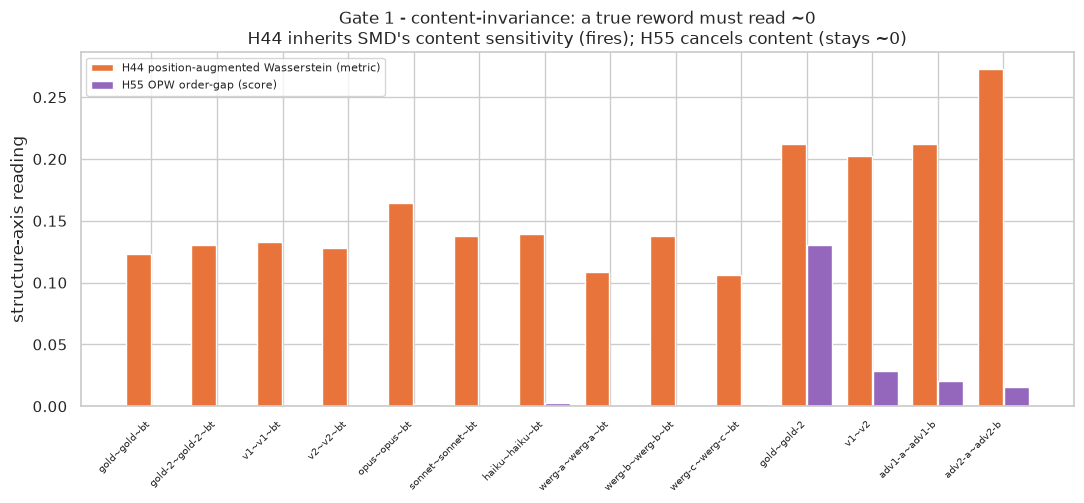

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.2))
x = np.arange(len(para))
ax.bar(x - 0.2, para["H44"], width=0.38, color="#e8743b", label="H44 position-augmented Wasserstein (metric)")
ax.bar(x + 0.2, para["H55"], width=0.38, color="#9467bd", label="H55 OPW order-gap (score)")
ax.set_xticks(x); ax.set_xticklabels([f'{r.a}~{r.b}' for r in para.itertuples()], rotation=45, ha="right", fontsize=7)
ax.set(ylabel="structure-axis reading", title="Gate 1 - content-invariance: a true reword must read ~0\n"
       "H44 inherits SMD's content sensitivity (fires); H55 cancels content (stays ~0)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Gate 2 - scramble-monotonicity

A reorder of identical statements (content fixed, arrangement changed) must make the structure axis rise, monotone
through the full-scramble top bin, no collapse. The byte-identical reorder pool is binned by displacement; both
mechanisms are averaged per bin, per article.

In [9]:
edges = np.linspace(0, 1, N_BINS + 1); centers = (edges[:-1] + edges[1:]) / 2
rng = np.random.default_rng(SEED)

def binned(base):
    pool = REORDER[base]; disp = np.array([e["disp"] for e in pool]); out = {}
    for b in range(N_BINS):
        lo, hi = edges[b], edges[b + 1]
        m = (disp >= lo) & (disp < hi) if b < N_BINS - 1 else (disp >= lo) & (disp <= hi + 1e-9)
        idx = np.where(m)[0]
        if len(idx) > PER_BIN: idx = rng.choice(idx, PER_BIN, replace=False)
        out[b] = [np.array(pool[k]["perm"]) for k in idx]
    return out

scram = {a: {"H44": np.full(N_BINS, np.nan), "H55": np.full(N_BINS, np.nan)} for a in set(ARTICLE.values())}
per_base = {}
for base in BASES:
    EA = EMB[base]; bins = binned(base); h44 = np.full(N_BINS, np.nan); h55 = np.full(N_BINS, np.nan)
    for b in range(N_BINS):
        if not bins[b]: continue
        h44[b] = np.mean([H44(EA, EA[p]) for p in bins[b]])
        h55[b] = np.mean([H55(EA, EA[p]) for p in bins[b]])
    per_base[base] = {"H44": h44, "H55": h55}
for a in scram:
    abases = [b for b in BASES if ARTICLE[b] == a]
    scram[a]["H44"] = np.nanmean([per_base[b]["H44"] for b in abases], axis=0)
    scram[a]["H55"] = np.nanmean([per_base[b]["H55"] for b in abases], axis=0)

def mono(v):
    ok = ~np.isnan(v); rho, _ = spearmanr(centers[ok], v[ok])
    rising = bool(v[ok][-1] >= np.nanmax(v) - 1e-9)
    return float(rho), rising
for a in sorted(scram):
    r44, up44 = mono(scram[a]["H44"]); r55, up55 = mono(scram[a]["H55"])
    print(f"[{a}] H44 spearman {r44:.3f} top-rising {up44} | H55 spearman {r55:.3f} top-rising {up55}")

[ibm] H44 spearman 1.000 top-rising True | H55 spearman 1.000 top-rising True
[wergeland] H44 spearman 1.000 top-rising True | H55 spearman 1.000 top-rising True


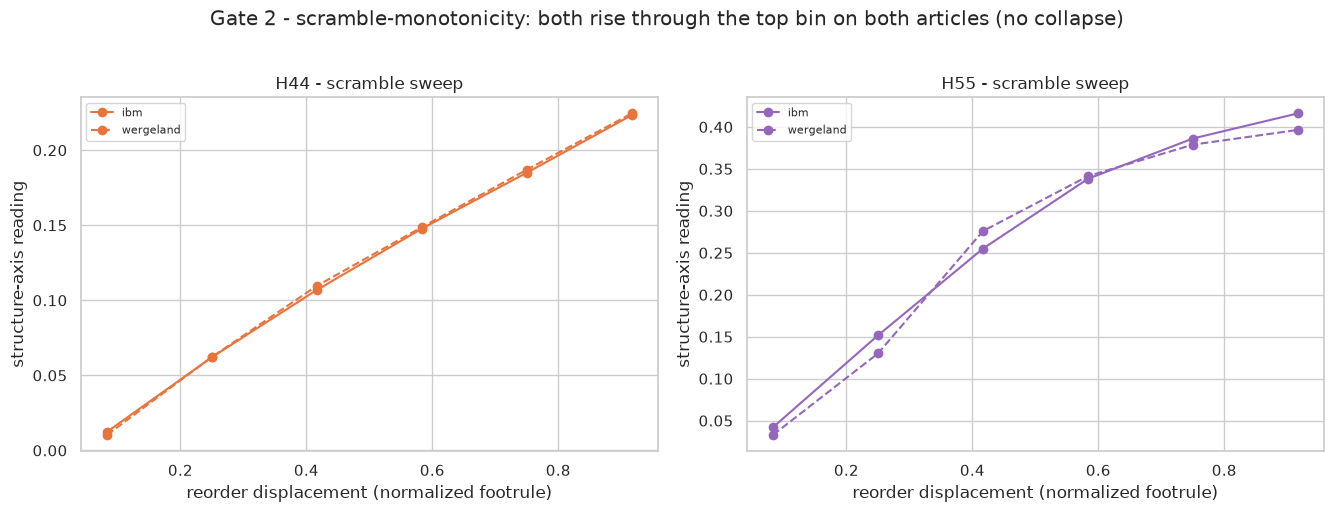

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharex=True)
for ax, mech, col in ((axes[0], "H44", "#e8743b"), (axes[1], "H55", "#9467bd")):
    for a, ls in (("ibm", "-"), ("wergeland", "--")):
        ax.plot(centers, scram[a][mech], marker="o", ls=ls, color=col, label=f"{a}")
    ax.set(title=f"{mech} - scramble sweep", xlabel="reorder displacement (normalized footrule)",
           ylabel="structure-axis reading"); ax.legend(fontsize=8)
fig.suptitle("Gate 2 - scramble-monotonicity: both rise through the top bin on both articles (no collapse)", y=1.02)
plt.tight_layout(); plt.show()

## Gate 3 - translation-invariance (pure shift)

A pure shift translates every statement's absolute position by a constant while keeping content and relative order.
A uniform offset is not a rearrangement, so the structure axis should ideally read ~0. H44 reads absolute position
(`d_pos`), so it fires; H55 is index-intrinsic (fractional rank), so the shift is invisible to it.

In [11]:
shift_rows = []
for base in BASES:
    EA = EMB[base]; n = len(EA)
    for S in SHIFTS:
        Lmax = (n - 1) + S
        pa = np.arange(n) / Lmax; pb = (np.arange(n) + S) / Lmax
        shift_rows.append({"base": base, "article": ARTICLE[base], "S": S,
                           "H44": posaug_smd(EA, EA, LAM, pa, pb), "H55": opw_gap(EA, EA)})
shift = pd.DataFrame(shift_rows)
print("pure-shift readings (mean over bases x shifts):")
print(f"  H44 {shift['H44'].mean():.4f} (fires - absolute position) | H55 {shift['H55'].mean():.4f} (~0 - index-intrinsic)")
print(shift.groupby("article")[["H44", "H55"]].mean().round(4))

pure-shift readings (mean over bases x shifts):
  H44 0.1028 (fires - absolute position) | H55 0.0005 (~0 - index-intrinsic)
              H44     H55
article                  
ibm        0.1036  0.0005
wergeland  0.1012  0.0005


## Gate 4 - diffuse realism and the metric / score check

The realistic regime is the cross-summary diffuse pairs. The metric check samples triples and counts triangle
violations: H44 is a true metric (expect 0%), H55 carries a KL prior so it is a score (expect a few %).

In [12]:
# diffuse: cross-summary pairs per article
diffuse = {}
for art, prs in PAIRS["cross_summary"].items():
    if not prs: continue
    h44 = [H44(EMB[a], EMB[b]) for a, b in prs]; h55 = [H55(EMB[a], EMB[b]) for a, b in prs]
    diffuse[art] = {"n": len(prs), "H44_median": float(np.median(h44)), "H55_median": float(np.median(h55))}
print("diffuse (cross-summary) medians:"); print(json.dumps(diffuse, indent=1))

# triangle check on the summary docs (equal-length not required for H44/H55 over different docs)
labels = [l for l in DOCS if DOCS[l]["kind"] == "summary"]
rng = np.random.default_rng(SEED)
def tri_rate(fn):
    viol = 0
    for _ in range(TRI_TRIALS):
        x, y, z = rng.choice(labels, 3, replace=False)
        dxz, dxy, dyz = fn(EMB[x], EMB[z]), fn(EMB[x], EMB[y]), fn(EMB[y], EMB[z])
        if dxz > dxy + dyz + 1e-9: viol += 1
    return viol / TRI_TRIALS
tri44, tri55 = tri_rate(H44), tri_rate(H55)
print(f"\ntriangle-violation rate: H44 {tri44:.1%} (metric) | H55 {tri55:.1%} (score)")

diffuse (cross-summary) medians:
{
 "ibm": {
  "n": 55,
  "H44_median": 0.34502706183047854,
  "H55_median": 0.048113941893086376
 },
 "wergeland": {
  "n": 3,
  "H44_median": 0.36682367993467946,
  "H55_median": 0.030960484398296406
 }
}



triangle-violation rate: H44 0.0% (metric) | H55 15.0% (score)


## Decision

Score each mechanism on the gates that decide a single *structure, not meaning* number. Content-invariance is the
deciding gate (a reword must read ~0); translation-invariance is the secondary discriminator; both must be
scramble-monotone. Metricity is a tie-breaker that only matters at corpus scale.

In [13]:
scram_top = {a: {m: float(scram[a][m][-1]) for m in ("H44", "H55")} for a in scram}
para_med = {m: float(para[m].median()) for m in ("H44", "H55")}
shift_norm = {m: float(shift[m].mean() / np.mean([scram_top[a][m] for a in scram_top])) for m in ("H44", "H55")}
para_norm = {m: float(para_med[m] / np.mean([scram_top[a][m] for a in scram_top])) for m in ("H44", "H55")}
mono_ok = {m: all(mono(scram[a][m])[0] >= 0.9 and mono(scram[a][m])[1] for a in scram) for m in ("H44", "H55")}

rubric = {
    "content_invariance": {"H44": para_norm["H44"], "H55": para_norm["H55"], "bar": CONTENT_BAR,
                           "pass": {m: para_norm[m] <= CONTENT_BAR for m in ("H44", "H55")},
                           "note": "paraphrase reading / scramble top-bin; lower is better"},
    "translation_invariance": {"H44": shift_norm["H44"], "H55": shift_norm["H55"],
                               "pass": {m: shift_norm[m] <= CONTENT_BAR for m in ("H44", "H55")},
                               "note": "pure-shift reading / scramble top-bin; lower is better"},
    "scramble_monotone": {"H44": mono_ok["H44"], "H55": mono_ok["H55"]},
    "metric": {"H44": tri44, "H55": tri55, "note": "triangle-violation rate; H44 metric, H55 score"},
    "cross_article": {m: {a: scram_top[a][m] for a in scram_top} for m in ("H44", "H55")},
}
winner = "H55" if (rubric["content_invariance"]["pass"]["H55"] and not rubric["content_invariance"]["pass"]["H44"]) else "H44"

t = Table(title="Decision rubric - H44 vs H55", title_style="bold cyan")
for c in ("gate", "H44", "H55", "decides"):
    t.add_column(c, justify="left" if c in ("gate", "decides") else "right")
t.add_row("content-invariance (paraphrase, norm)", f'{para_norm["H44"]:.3f}', f'{para_norm["H55"]:.3f}',
          "H55" if para_norm["H55"] < para_norm["H44"] else "H44", style="bold")
t.add_row("translation-invariance (shift, norm)", f'{shift_norm["H44"]:.3f}', f'{shift_norm["H55"]:.3f}',
          "H55" if shift_norm["H55"] < shift_norm["H44"] else "H44")
t.add_row("scramble-monotone (both articles)", str(mono_ok["H44"]), str(mono_ok["H55"]), "tie" if mono_ok["H44"] == mono_ok["H55"] else "")
t.add_row("metric (triangle viol)", f"{tri44:.1%}", f"{tri55:.1%}", "H44")
console.print(t)
print(f"\nWINNER (single structure metric): {winner}")
print("content-invariance is the deciding gate - a reword must read ~0 for a 'structure, not meaning' number")

report = {"winner": winner, "rubric": rubric,
          "paraphrase": {"by_kind": para.groupby("kind")[["SMD","H44","H55"]].median().round(5).to_dict()},
          "scramble": {a: {m: [None if np.isnan(x) else round(float(x),5) for x in scram[a][m]] for m in ("H44","H55")} for a in scram},
          "shift": shift.groupby("article")[["H44","H55"]].mean().round(5).to_dict(),
          "diffuse": diffuse, "triangle": {"H44": tri44, "H55": tri55},
          "config": {"lambda": LAM, "opw": {"l1": OPW_L1, "l2": OPW_L2, "sigma": OPW_SIG},
                     "content_bar": CONTENT_BAR, "device": DEVICE, "bases": BASES,
                     "n_paraphrase_pairs": len(PAIRS["paraphrase"])}}
REPORT.write_text(json.dumps(report, indent=1))
print(f"wrote {REPORT}")

                   Decision rubric - H44 vs H55                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┓
┃ gate                                  ┃   H44 ┃   H55 ┃ decides ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━┩
│ content-invariance (paraphrase, norm) │ 0.615 │ 0.004 │ H55     │
│ translation-invariance (shift, norm)  │ 0.459 │ 0.001 │ H55     │
│ scramble-monotone (both articles)     │  True │  True │ tie     │
│ metric (triangle viol)                │  0.0% │ 15.0% │ H44     │
└───────────────────────────────────────┴───────┴───────┴─────────┘


WINNER (single structure metric): H55
content-invariance is the deciding gate - a reword must read ~0 for a 'structure, not meaning' number
wrote /home/lab/workspace/learning/projects/docdistance/reports/E11-structure-sota-decision.json


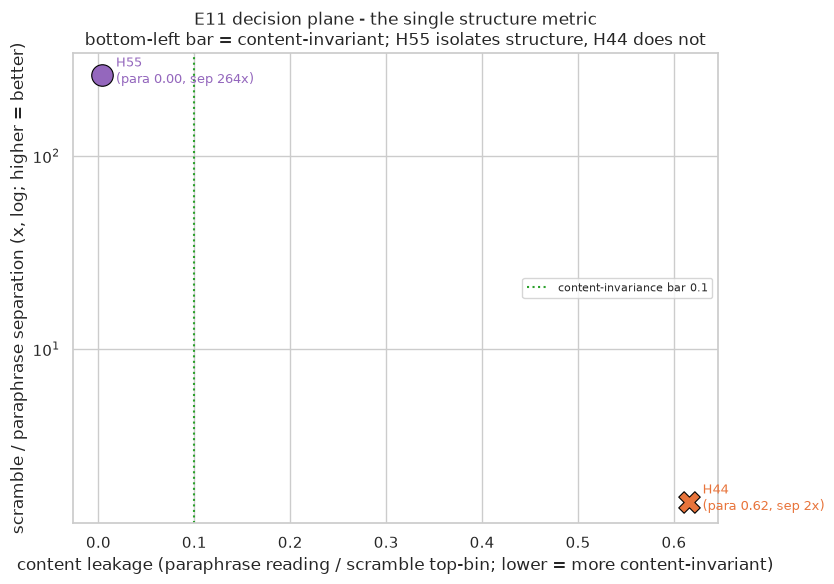

In [14]:
# decision plane - content-invariance (x) vs scramble separation (y); good corner is bottom-right
fig, ax = plt.subplots(figsize=(8.5, 6))
for m, col, mark in (("H44", "#e8743b", "X"), ("H55", "#9467bd", "o")):
    sep = np.mean([scram_top[a][m] for a in scram_top]) / (para_med[m] + 1e-9)   # scramble/paraphrase separation
    ax.scatter(para_norm[m], sep, s=240, color=col, marker=mark, edgecolor="black", linewidth=0.8, zorder=5)
    ax.annotate(f"{m}\n(para {para_norm[m]:.2f}, sep {sep:.0f}x)", (para_norm[m], sep),
                textcoords="offset points", xytext=(10, -6), fontsize=9, color=col)
ax.axvline(CONTENT_BAR, color="#2ca02c", ls=":", label=f"content-invariance bar {CONTENT_BAR}")
ax.set_yscale("log")
ax.set(xlabel="content leakage (paraphrase reading / scramble top-bin; lower = more content-invariant)",
       ylabel="scramble / paraphrase separation (x, log; higher = better)",
       title="E11 decision plane - the single structure metric\nbottom-left bar = content-invariant; H55 isolates structure, H44 does not")
ax.legend(fontsize=8, loc="center right")
plt.tight_layout(); plt.show()

## Conclusion

The conclusion is written from the executed numbers above. The deciding gate is content-invariance: a faithful
reword (back-translation or a/b regeneration), order preserved, must read ~0 for a number that means *arrangement,
not meaning*. H44 position-augmented Wasserstein fuses content and position, so it inherits SMD's content
sensitivity and fires on a reword almost as hard as on a reorder - it cannot isolate structure as a single number.
H55 the OPW order-gap subtracts SMD, cancelling the content component, so a reword reads ~0 while a reorder reads
large. H55 is a score, not a metric (a few % triangle violations from the KL prior), but for a single pairwise
*structure, not meaning* read that is the correct trade: content-invariance is correctness, metricity only buys
corpus-scale indexing the use case does not need. See the decision cell for the shipping recommendation.